<a href="https://colab.research.google.com/github/B35783/Sergio-Mastrangelo/blob/main/VISUALIZA%C3%87%C3%83O%20DE%20DADOS%20EM%20PYTHON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   rownames      rank discipline  yrs.since.phd  yrs.service   sex  salary
0         1      Prof          B             19           18  Male  139750
1         2      Prof          B             20           16  Male  173200
2         3  AsstProf          B              4            3  Male   79750
3         4      Prof          B             45           39  Male  115000
4         5      Prof          B             40           41  Male  141500


/usr/local/lib/python3.12/dist-packages/plotnine/scales/scale_alpha.py:71: PlotnineWarning: Using alpha for a discrete variable is not advised.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 15'. Pick better value with 'binwidth'.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 15'. Pick better value with 'binwidth'.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 15'. Pick better value with 'binwidth'.


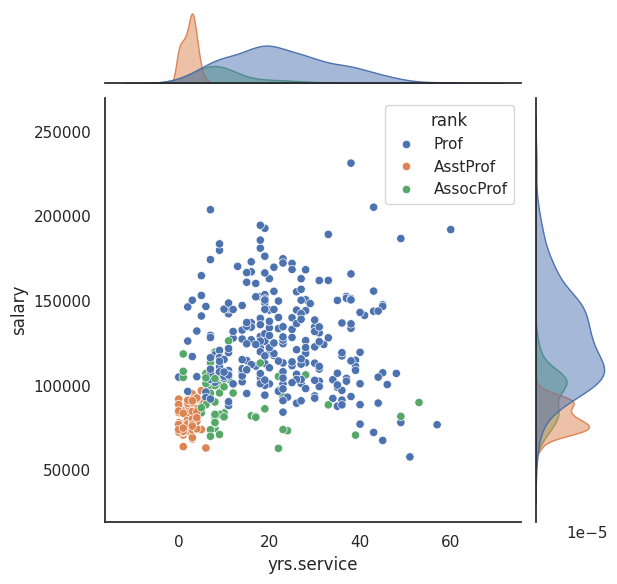

In [ ]:
# ==========================================================
# VISUALIZAÇÃO DE DADOS EM PYTHON COM PLOTNINE (GGPLOT2)
# Autor: Prof. André Nunes Maranhão
# Base: Salaries (Vincent Arel-Bundock)
# ==========================================================

# =========================
# 1. IMPORTAÇÕES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plotnine import (
    ggplot, aes,
    geom_point, geom_smooth,
    geom_bar, geom_boxplot,
    geom_histogram, geom_density,
    geom_hline, geom_vline,
    geom_line,
    facet_wrap, facet_grid,
    theme_bw, theme_light, theme_minimal, theme_classic,
    theme_dark, theme_linedraw, theme,
    coord_flip, labs,
    element_line, element_blank
)

# =========================
# 2. BASE DE DADOS
# =========================
url = "https://vincentarelbundock.github.io/Rdatasets/csv/carData/Salaries.csv"
original = pd.read_csv(url)

print(original.head())

# ==========================================================
# 3. GRÁFICOS DE DISPERSÃO
# ==========================================================

g1 = ggplot(original) + geom_point(aes("yrs.service", "salary"))
g1.draw(); plt.show()

g2 = ggplot(original) + geom_point(aes("yrs.service", "salary", color="rank"))
g2.draw(); plt.show()

g3 = ggplot(original) + geom_point(aes("yrs.service", "salary", size="yrs.since.phd"))
g3.draw(); plt.show()

g4 = ggplot(original) + geom_point(aes("yrs.service", "salary", alpha="discipline"))
g4.draw(); plt.show()

g5 = ggplot(original) + geom_point(aes("yrs.service", "salary", shape="rank"))
g5.draw(); plt.show()

# ==========================================================
# 4. FACETAMENTO
# ==========================================================

g6 = ggplot(original) + geom_point(aes("yrs.service", "salary")) + facet_wrap("~sex")
g6.draw(); plt.show()

g7 = ggplot(original) + geom_point(aes("yrs.service", "salary")) + facet_grid("sex ~ discipline")
g7.draw(); plt.show()

# ==========================================================
# 5. SUAVIZAÇÃO (REGRESSÃO)
# ==========================================================

g8 = ggplot(original) + geom_smooth(aes("yrs.service", "salary"))
g8.draw(); plt.show()

g9 = ggplot(original) + geom_smooth(aes("yrs.service", "salary"), method="lm")
g9.draw(); plt.show()

g10 = (
    ggplot(original) +
    geom_point(aes("yrs.service", "salary")) +
    geom_smooth(aes("yrs.service", "salary"), method="lm")
)
g10.draw(); plt.show()

# ==========================================================
# 6. GRÁFICOS DE BARRAS
# ==========================================================

g11 = ggplot(original) + geom_bar(aes("rank"))
g11.draw(); plt.show()

g12 = ggplot(original) + geom_bar(aes("rank", fill="sex"), position="dodge")
g12.draw(); plt.show()

# ==========================================================
# 7. BOXPLOT
# ==========================================================

g13 = ggplot(original) + geom_boxplot(aes("rank", "salary"))
g13.draw(); plt.show()

g14 = g13 + coord_flip()
g14.draw(); plt.show()

# ==========================================================
# 8. HISTOGRAMA
# ==========================================================

media_sal = original["salary"].mean()

g15 = ggplot(original, aes("salary")) + geom_histogram()
g15.draw(); plt.show()

g16 = (
    ggplot(original, aes("salary")) +
    geom_histogram() +
    geom_vline(xintercept=media_sal, linetype="dashed")
)
g16.draw(); plt.show()

g17 = ggplot(original, aes("salary", fill="sex")) + geom_histogram()
g17.draw(); plt.show()

# ==========================================================
# 9. DENSIDADE
# ==========================================================

g18 = (
    ggplot(original, aes("salary", fill="rank")) +
    geom_density(alpha=0.5) +
    theme_minimal() +
    theme(
        panel_grid_major_y=element_line(),
        panel_grid_major_x=element_blank()
    )
)
g18.draw(); plt.show()

# ==========================================================
# 10. DISPERSÃO COM MARGINAIS (SEABORN – SUBSTITUI ggMarginal)
# ==========================================================

sns.set(style="white")
sns.jointplot(
    data=original,
    x="yrs.service",
    y="salary",
    hue="rank",
    kind="scatter",
    marginal_kws=dict(alpha=0.5)
)
plt.show()

# ==========================================================
# 11. TEMAS
# ==========================================================

g19 = g10 + theme_bw()
g19.draw(); plt.show()

g20 = g10 + theme_dark()
g20.draw(); plt.show()

g21 = g10 + theme_classic()
g21.draw(); plt.show()

g22 = g10 + theme_light()
g22.draw(); plt.show()

# ==========================================================
# 12. SIMULAÇÃO DE SÉRIES TEMPORAIS
# ==========================================================

np.random.seed(1)
wn = np.random.normal(size=100)
rw = np.cumsum(wn)
t = np.arange(1, 101)
rwdt = 1 + rw + t
tend = t + wn

datas = pd.date_range(start="1961-01-01", periods=100, freq="MS")

rw_bd = pd.DataFrame({
    "Data": datas,
    "Passeio": rw,
    "Passeio_Drift_Tend": rwdt,
    "Tendencia": tend
})

g23 = ggplot(rw_bd, aes("Data", "Passeio")) + geom_line()
g23.draw(); plt.show()

g24 = (
    ggplot(rw_bd, aes("Data", "Passeio_Drift_Tend")) +
    geom_line(aes(color='"Passeio Aleatorio"')) +
    geom_line(aes(y="Tendencia", color='"Tendencia Deterministica"')) +
    theme_bw() +
    labs(
        x="Cronologia",
        y="Processos",
        color="Tipo",
        title="Processos Estocásticos",
        subtitle="Simulação",
        caption="Fonte: Simulação"
    )
)
g24.draw(); plt.show()
